In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from google.colab import drive
drive.mount('/content/drive')

file = "drive/MyDrive/dataset/train.csv"

Mounted at /content/drive


In [ ]:
df = pd.read_csv(file)

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


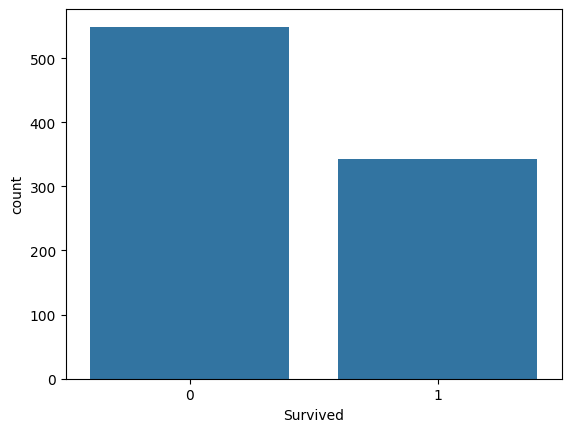

In [ ]:
sns.countplot(x='Survived',data=df)
plt.show()

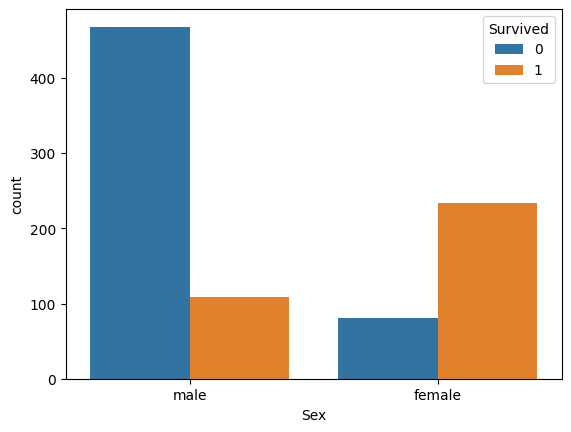

In [ ]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.show()

In [ ]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [ ]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [ ]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [ ]:
df.groupby(['Embarked','Survived']).size()

Embarked  Survived
C         0            75
          1            93
Q         0            47
          1            30
S         0           427
          1           217
dtype: int64

In [ ]:
df.groupby(['Embarked','Survived'])['Parch'].describe()

count      mean       std  min  25%  50%  75%  max
Embarked Survived                                                    
C        0          75.0  0.253333  0.547558  0.0  0.0  0.0  0.0  2.0
         1          93.0  0.451613  0.730041  0.0  0.0  0.0  1.0  3.0
Q        0          47.0  0.276596  0.826257  0.0  0.0  0.0  0.0  5.0
         1          30.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0
S        0         427.0  0.348946  0.862640  0.0  0.0  0.0  0.0  6.0
         1         217.0  0.539171  0.821914  0.0  0.0  0.0  1.0  5.0

In [ ]:
df['Cabin'].nunique()

147

In [ ]:
df['Cabin']

,Cabin
0,NaN
1,C85
2,NaN
3,C123
4,NaN
...,...
886,NaN
887,B42
888,NaN
889,C148


In [ ]:
df.groupby(['Survived','SibSp']).size()

Survived  SibSp
0         0        398
          1         97
          2         15
          3         12
          4         15
          5          5
          8          7
1         0        210
          1        112
          2         13
          3          4
          4          3
dtype: int64

<Axes: >

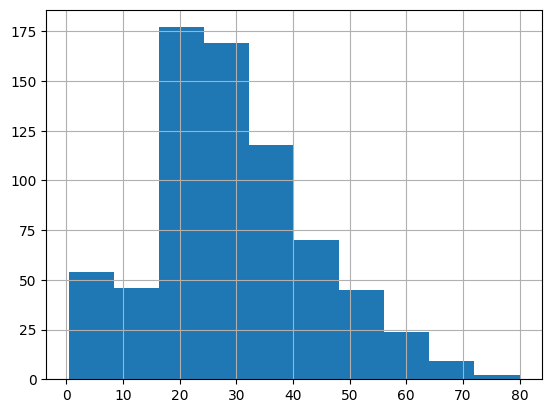

In [ ]:
df['Age'].hist()

<Axes: xlabel='Survived', ylabel='Age'>

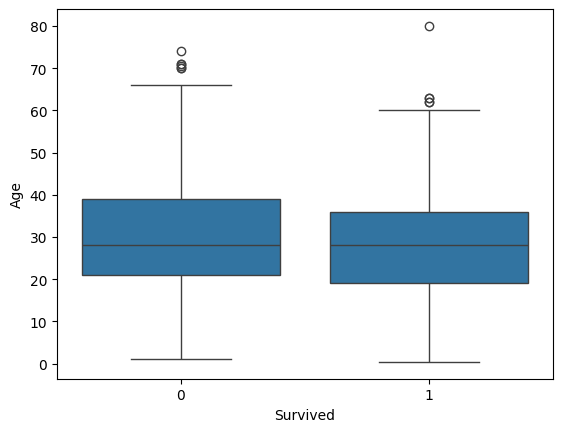

In [ ]:
sns.boxplot(x='Survived',y='Age',data=df)

<Axes: >

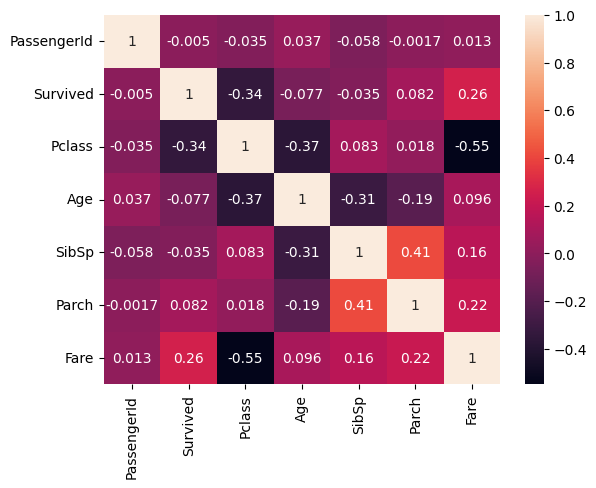

In [ ]:
sns.heatmap(df.select_dtypes(include='number'))

In [ ]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [ ]:
#preprocessing
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

gender = LabelEncoder()
df['Sex'] = gender.fit_transform(df['Sex'])

le_embarked = LabelEncoder()
df['Embarked'] = le_embarked.fit_transform(df['Embarked'])

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

scaler = StandardScaler()
df[['Age', 'Fare', 'FamilySize']] = scaler.fit_transform(df[['Age', 'Fare', 'FamilySize']])


display(df.head())
display(df.info())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,0,3,1,-0.565736,1,0,-0.502445,2,0.059160
1,1,1,0,0.663861,1,0,0.786845,0,0.059160
2,1,3,0,-0.258337,0,0,-0.488854,2,-0.560975
3,1,1,0,0.433312,1,0,0.420730,2,0.059160
4,0,3,1,0.433312,0,0,-0.486337,2,-0.560975


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked    891 non-null    int64  
 8   FamilySize  891 non-null    float64
dtypes: float64(3), int64(6)
memory usage: 62.8 KB


None

In [ ]:
X = df.drop(['Survived'], axis=1, errors='ignore')
y = df['Survived']

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_smote, y_smote = smote.fit_resample(X, y)
y_smote.value_counts()

,count
Survived,
0,549
1,549


,count
Survived,
0,549
1,549


In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
def train_evaluate(y_pred, X_tr, y_tr, X_te, y_te, model_name='Model'):
    print('Accuracy:', accuracy_score(y_te, y_pred))
    print('Classification Report:\n', classification_report(y_te, y_pred))
    print(sns.heatmap(confusion_matrix(y_te, y_pred), annot=True))
    plt.show()

    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.legend()
    plt.show()



Accuracy: 0.7541899441340782
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.86      0.82       113
           1       0.70      0.58      0.63        66

    accuracy                           0.75       179
   macro avg       0.74      0.72      0.72       179
weighted avg       0.75      0.75      0.75       179

Axes(0.125,0.11;0.62x0.77)


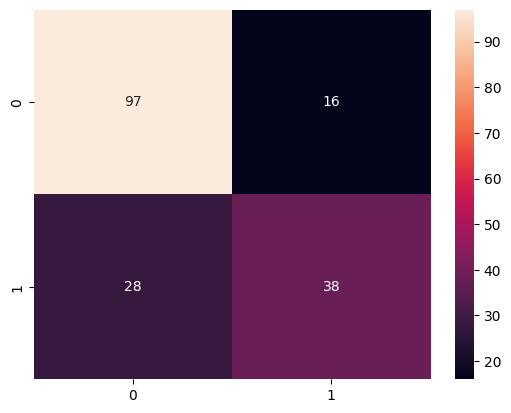

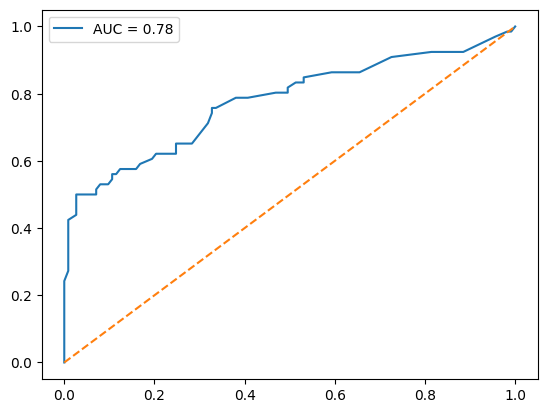

In [ ]:
model = AdaBoostClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
train_evaluate(y_pred, X_train, y_train, X_test, y_test, 'AdaBoost')


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:36:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.7932960893854749
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.82      0.82       105
           1       0.75      0.76      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179

Confusion Matrix:
 [[86 19]
 [18 56]]


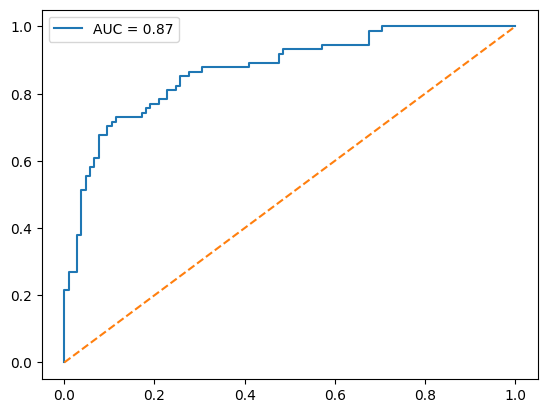

Sex           0.548593
Pclass        0.206391
SibSp         0.095058
FamilySize    0.037164
Fare          0.030793
Age           0.029985
Parch         0.027460
Embarked      0.024555
dtype: float32


<Axes: >

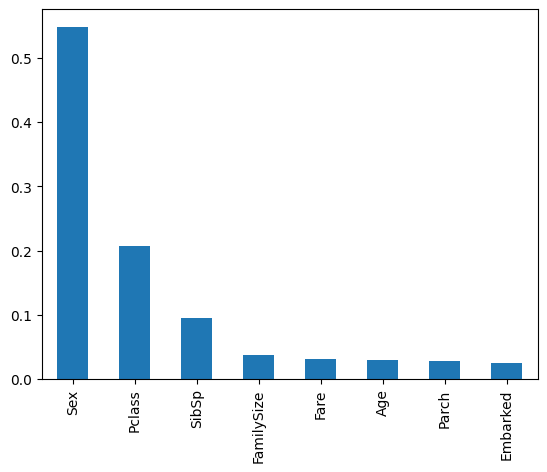

In [ ]:
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
train_evaluate(y_pred, X_train, y_train, X_test, y_test, 'XGBoost')

feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)
feat_importances = feat_importances.sort_values(ascending=False)

print(feat_importances)

feat_importances.plot(kind='bar')

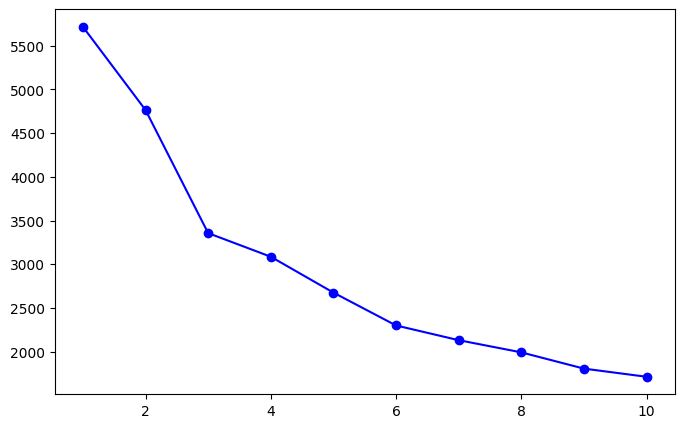

In [ ]:
#elbow
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score


inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-')

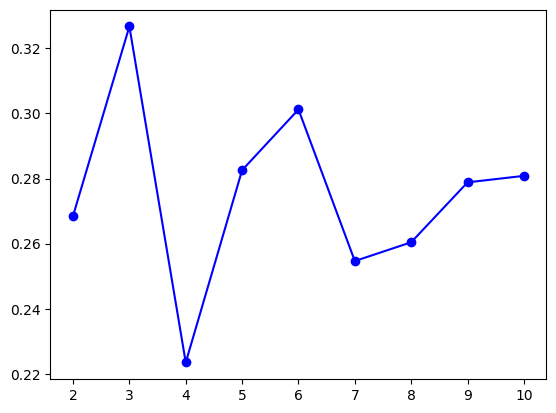

In [ ]:
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.plot(K_range, silhouette_scores, 'bo-')

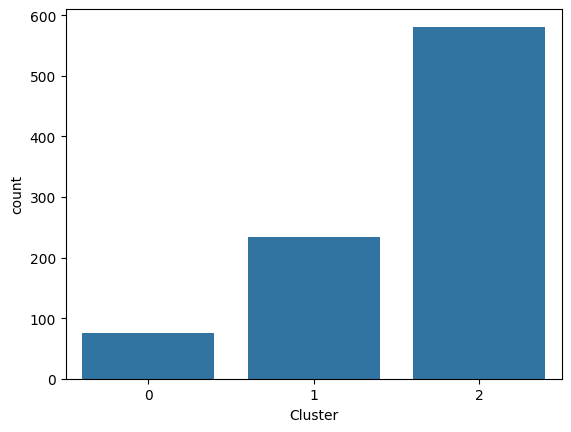

In [ ]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X)

df['Cluster'] = clusters

sns.countplot(x='Cluster', data=df)
plt.show()


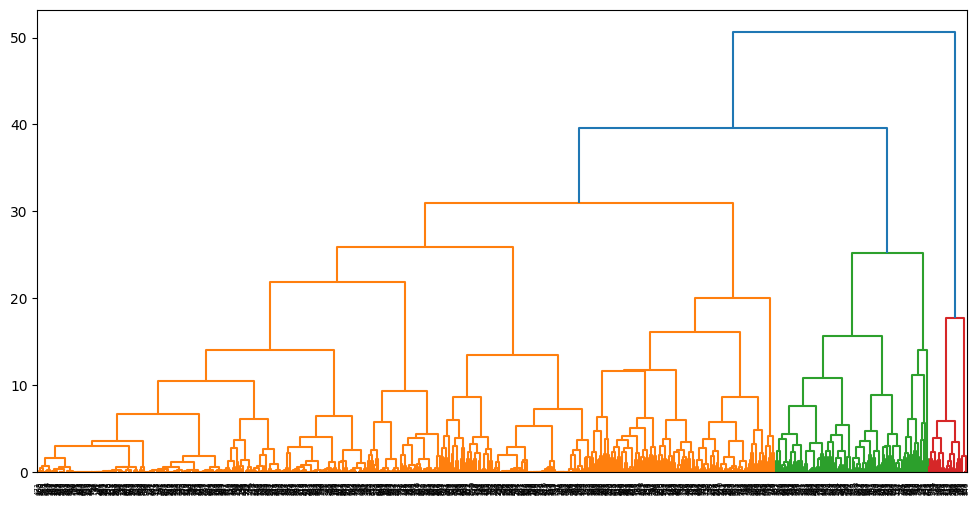

In [ ]:
linked = linkage(X, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False)

plt.show()



In [ ]:


clusters = fcluster(linked, 10, criterion='distance')
df['AggCluster'] = clusters

numeric_cols = df.select_dtypes(include='number').columns

print("Cluster-wise numeric feature means:")
print(df.groupby('AggCluster')[numeric_cols].mean())

for col in ['Sex', 'Embarked', 'Survived']:
    print(f"\nDistribution of {col} by AggCluster:")
    print(pd.crosstab(df['AggCluster'], df[col], normalize='index').round(2))


Cluster-wise numeric feature means:
            Survived    Pclass       Sex       Age     SibSp     Parch  \
AggCluster                                                               
1           0.000000  3.000000  0.571429 -0.104637  8.000000  2.000000   
2           0.100000  3.000000  0.633333 -1.703114  3.933333  1.600000   
3           1.000000  1.000000  0.666667  0.458928  0.000000  0.333333   
4           0.666667  1.000000  0.333333 -0.091829  2.333333  2.333333   
5           0.666667  1.000000  0.333333  0.376955  0.133333  0.733333   
6           0.720000  1.020000  0.400000  0.657713  0.800000  0.140000   
7           0.653846  1.000000  0.538462  1.775228  0.615385  0.423077   
8           0.638298  1.085106  0.531915  0.070319  0.234043  0.021277   
9           0.181818  2.909091  0.181818  0.922356  0.727273  4.454545   
10          0.257576  2.636364  0.575758 -0.032445  1.333333  0.060606   
11          0.837838  2.486486  0.486486 -1.659642  0.621622  1.189189   
12